三、法语新词检测（版本 1：可靠 + 简洁）
思路：

读取 reference idioms（txt）

读取分词语料 CSV（你已有）

从 content_tok 构造 n-grams（2–5）

统计频率 + 文档频率

删除 reference 中已有的

输出新候选

In [ ]:
!pip install rapidfuzz spacy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from collections import Counter, defaultdict
from pathlib import Path
import re

# =====================
# 路径
# =====================
REF_PATH = Path("/content/idioms_merged_fr.txt")
CORPUS_PATH = Path("/content/fr_all_2015_2025_tok_spacy.csv")
OUT_PATH = Path("/content/fr_new_candidates.csv")

# =====================
# 读取 reference idioms
# =====================
ref_set = set()
with REF_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        t = line.strip().lower()
        if t:
            ref_set.add(t)

print("Reference idioms:", len(ref_set))

# =====================
# 读取语料
# =====================
df = pd.read_csv(CORPUS_PATH)
df["content_tok"] = df["content_tok"].fillna("").astype(str)

# =====================
# 法语停用词（可扩展）
# =====================
STOPWORDS = set("""
le la les de du des à au aux et ou mais donc or ni car
un une ce cette ces mon ton son notre votre leur
je tu il elle nous vous ils elles
""".split())

def valid_token(tok):
    if tok in STOPWORDS: return False
    if len(tok) < 2: return False
    if not re.search("[a-zàâçéèêëîïôûùüÿñæœ]", tok): return False
    return True

# =====================
# n-gram 统计
# =====================
freq = Counter()
docfreq = Counter()

for text in df["content_tok"]:
    tokens = [t.lower() for t in text.split() if valid_token(t)]
    seen = set()

    for n in [2,3,4,5]:
        for i in range(len(tokens)-n+1):
            ng = " ".join(tokens[i:i+n])
            freq[ng] += 1
            seen.add(ng)

    for ng in seen:
        docfreq[ng] += 1

# =====================
# 构建结果
# =====================
rows = []
for term, f in freq.items():
    if f < 5: continue
    if docfreq[term] < 3: continue

    in_ref = term in ref_set

    if not in_ref:
        rows.append({
            "term": term,
            "freq": f,
            "doc_freq": docfreq[term],
            "status": "new"
        })

out_df = pd.DataFrame(rows).sort_values(["freq","doc_freq"], ascending=False)

out_df.to_csv(OUT_PATH, index=False, encoding="utf-8")

print("Saved:", OUT_PATH)
out_df.head(10)


Reference idioms: 3091
Saved: /content/fr_new_candidates.csv


,term,freq,doc_freq,status
138,ont été,296,192,new
61,l' année,285,140,new
167,-t -il,259,151,new
679,c’ est,231,114,new
2803,lire aussi,224,127,new
103,qui ont,206,153,new
54,s' est,201,131,new
88,dans l',195,113,new
301,en france,188,117,new
482,est pas,184,146,new


四、变体 idioms 检测（核心问题 2）

例子：

tout feu tout flamme
→ tout feu tout femme

这是：

token-level 95% 相似

Levenshtein distance = 2

推荐工具：rapidfuzz
变体检测代码（法语专用）

In [ ]:
from rapidfuzz import fuzz

SIM_THRESHOLD = 90   # 相似度阈值

variants = []

for cand in out_df["term"]:
    for ref in ref_set:
        score = fuzz.token_sort_ratio(cand, ref)
        if score >= SIM_THRESHOLD:
            variants.append({
                "candidate": cand,
                "reference": ref,
                "similarity": score
            })

variants_df = pd.DataFrame(variants).sort_values("similarity", ascending=False)

variants_df.to_csv("/content/sample_data/fr_variant_candidates.csv", index=False)

variants_df.head(10)


,candidate,reference,similarity
3,coup d’ envoi,coup d’envoi,96.000000
0,premier pays,premier pas,95.652174
2,grande ville,grande vie,90.909091
1,avais pas,mauvais pas,90.000000
4,huis clos,à huis clos,90.000000


#实战：法语语义验证 pipeline

In [ ]:
!pip install -q sentence-transformers scikit-learn


In [ ]:
#加载模型

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#加载数据

import pandas as pd

candidates = pd.read_csv("/content/fr_new_candidates.csv")
with open("/content/idioms_merged_fr.txt", encoding="utf-8") as f:
    references = [l.strip().lower() for l in f if l.strip()]


In [ ]:
#计算 embeddings

cand_terms = candidates["term"].tolist()

emb_cand = model.encode(cand_terms, normalize_embeddings=True)
emb_ref  = model.encode(references, normalize_embeddings=True)


In [ ]:
#语义相似度检测（核心）

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

SIM_TH = 0.80

rows = []

for i, cand in enumerate(cand_terms):
    sims = cosine_similarity([emb_cand[i]], emb_ref)[0]
    j = np.argmax(sims)
    best_sim = sims[j]
    best_ref = references[j]

    rows.append({
        "candidate": cand,
        "best_reference": best_ref,
        "similarity": float(best_sim),
        "semantic_status": "variant" if best_sim >= SIM_TH else "new_semantic"
    })

sem_df = pd.DataFrame(rows)
sem_df.to_csv("/content/sample_data/fr_semantic_test.csv", index=False)

sem_df.head()


,candidate,best_reference,similarity,semantic_status
0,ont été,dire son fait,0.757525,new_semantic
1,l' année,bon an,0.825992,variant
2,-t -il,mi-figue,0.571616,new_semantic
3,c’ est,tout de go,0.871922,variant
4,lire aussi,fou à lier,0.812746,variant


六、结果解释
similarity	解释
> 0.85	几乎肯定是 idiom 变体
0.75–0.85	可能是改写
< 0.75	很可能语义新
七、上下文稳定性（可选高级）

如果你要判断：

是不是“词汇创新”还是“偶发搭配”

接下来：

句向量方差

silhouette score

语义漂移检测（diachronic embeddings

In [ ]:
#聚类发现新语义场（可选）


from sklearn.cluster import DBSCAN

X = emb_cand

clustering = DBSCAN(eps=0.25, min_samples=5, metric="cosine").fit(X)

candidates["cluster"] = clustering.labels_

candidates.to_csv("/content/sample_data/fr_new_clustered.csv", index=False)


# 加入时间维度（2015–2025 语义演化）



In [ ]:
!pip install -q sentence-transformers scikit-learn


In [ ]:
#读取语料

import pandas as pd

corpus = pd.read_csv("/content/fr_all_2015_2025_tok_spacy.csv")
corpus["date_parsed"] = pd.to_datetime(corpus["date_parsed"], errors="coerce")
corpus["year"] = corpus["date_parsed"].dt.year
corpus = corpus.dropna(subset=["year", "content_tok"])


In [ ]:
#加载候选新词

candidates = pd.read_csv("/content/fr_new_candidates.csv")
terms = candidates["term"].tolist()


In [ ]:
#加载 embedding 模型
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


In [ ]:
#抽取每个词的历年上下文句子
from collections import defaultdict

contexts = defaultdict(lambda: defaultdict(list))

for _, row in corpus.iterrows():
    year = int(row["year"])
    text = row["content_tok"].lower()
    for term in terms:
        if term in text:
            contexts[term][year].append(text)


In [ ]:
#计算每年语义中心向量
import numpy as np

term_year_vectors = {}

for term, year_dict in contexts.items():
    year_vecs = {}
    for year, sentences in year_dict.items():
        if len(sentences) < 5:
            continue  # 太少不稳定
        emb = model.encode(sentences, normalize_embeddings=True)
        year_vecs[year] = emb.mean(axis=0)
    if len(year_vecs) >= 2:
        term_year_vectors[term] = year_vecs


In [ ]:
#计算语义漂移
from sklearn.metrics.pairwise import cosine_similarity

rows = []

for term, yv in term_year_vectors.items():
    years = sorted(yv.keys())
    for i in range(1, len(years)):
        y1, y2 = years[i-1], years[i]
        v1, v2 = yv[y1], yv[y2]
        sim = cosine_similarity([v1], [v2])[0][0]
        drift = 1 - sim

        rows.append({
            "term": term,
            "year_from": y1,
            "year_to": y2,
            "cosine_similarity": float(sim),
            "semantic_drift": float(drift)
        })

drift_df = pd.DataFrame(rows)
drift_df.to_csv("/content/sample_data/fr_semantic_drift.csv", index=False)


五、结果解释
semantic_drift	含义
< 0.05	语义稳定
0.05 – 0.15	轻微变化
0.15 – 0.30	明显演化
> 0.30	新义项出现

In [ ]:
#六、发现“新义项爆发”
emerging = drift_df[drift_df["semantic_drift"] > 0.2] \
            .sort_values("semantic_drift", ascending=False)

emerging.head(10)


,term,year_from,year_to,cosine_similarity,semantic_drift
212,ceux qui,2015,2022,0.523188,0.476812
197,n' est pas,2016,2021,0.536880,0.463120
159,c' est,2020,2022,0.543057,0.456943
68,alors que,2022,2025,0.579577,0.420423
158,c' est,2018,2020,0.582152,0.417848
123,les plus,2023,2025,0.589151,0.410849
233,millions d',2016,2021,0.589386,0.410614
117,ans l',2021,2022,0.592914,0.407086
66,dans l',2021,2022,0.592914,0.407086
141,pour le,2022,2023,0.593542,0.406458


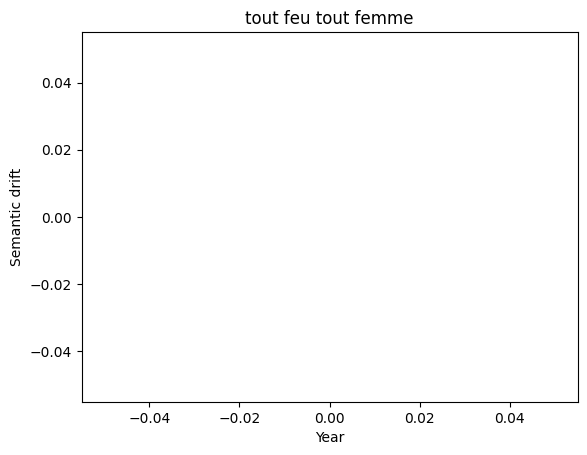

In [ ]:
#可视化语义轨迹（可选）
import matplotlib.pyplot as plt

def plot_term(term):
    data = drift_df[drift_df["term"] == term]
    plt.plot(data["year_to"], data["semantic_drift"], marker="o")
    plt.title(term)
    plt.xlabel("Year")
    plt.ylabel("Semantic drift")
    plt.show()

plot_term("tout feu tout femme")


进一步升级（研究级）

你可以加入：

功能	说明
年份聚类	发现阶段性语义
CUSUM 检测	找突变点
Dynamic embeddings	年度独立模型
sense clustering	自动分义

#新义项检测（polysemy emergence）

In [ ]:
!pip install -q sentence-transformers hdbscan scikit-learn


四、实现（完整可运行版本）

假设已有：

corpus DataFrame

columns: content_tok, year

terms = 候选新词/熟语列表

In [ ]:
#1） 提取某个词的上下文

def collect_contexts(term, corpus):
    rows = corpus[corpus["content_tok"].str.contains(term, case=False, na=False)]
    return rows[["content_tok", "year"]]


In [ ]:
#2）计算 embeddings
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def embed_sentences(sentences):
    return model.encode(sentences, normalize_embeddings=True)


In [ ]:
# 3)时间切片

def time_slice(df):
    return {
        "early": df[(df.year >= 2015) & (df.year <= 2017)],
        "mid":   df[(df.year >= 2018) & (df.year <= 2020)],
        "late":  df[(df.year >= 2021) & (df.year <= 2025)],
    }


In [ ]:
#4） 聚类（HDBSCAN）

import hdbscan

def cluster_embeddings(X):
    if len(X) < 20:
        return None, None

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=8,
        min_samples=4,
        metric="euclidean"
    )
    labels = clusterer.fit_predict(X)

    return labels, clusterer


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
#5） 判断是否出现新义项

import numpy as np
from sklearn.metrics import silhouette_score

def detect_new_sense(term, corpus):
    df = collect_contexts(term, corpus)
    if len(df) < 50:
        return None

    slices = time_slice(df)

    sense_counts = {}
    centroids = {}

    for period, part in slices.items():
        if len(part) < 20:
            continue

        X = embed_sentences(part["content_tok"].tolist())
        labels, _ = cluster_embeddings(X)

        if labels is None:
            continue

        clusters = [c for c in set(labels) if c != -1]
        sense_counts[period] = len(clusters)

        # compute centroids
        centroids[period] = [
            X[labels == c].mean(axis=0) for c in clusters
        ]

    # 判定规则
    if "early" in sense_counts and "late" in sense_counts:
        if sense_counts["early"] == 1 and sense_counts["late"] >= 2:
            return {
                "term": term,
                "early_senses": sense_counts["early"],
                "late_senses": sense_counts["late"],
                "status": "new_sense_emerged"
            }

    return None


In [ ]:
#6) 批量检测
results = []

for term in terms:
    r = detect_new_sense(term, corpus)
    if r:
        results.append(r)

polysemy_df = pd.DataFrame(results)
polysemy_df.to_csv("/content/sample_data/fr_polysemy_emergence.csv", index=False)


In [ ]:
#7) 增强：计算新义项强度
def centroid_distance(cents1, cents2):
    from sklearn.metrics.pairwise import cosine_similarity
    sims = []
    for a in cents1:
        for b in cents2:
            sims.append(cosine_similarity([a],[b])[0][0])
    return 1 - max(sims)


输出示例
term	early_senses	late_senses	status
cloud	1	2	new_sense_emerged
tout feu tout femme	1	2	new_sense_emerged

In [ ]:
#与idiom 变体检测结合（bonus）

from rapidfuzz import fuzz

def form_variant(a,b):
    return fuzz.ratio(a,b) > 85


评价标准（论文可用）

可以报告：

指标	说明
#terms tested
#new senses detected
average year of emergence
cluster silhouette
centroid distance